# Model Training — SVM for IDRiD Retinopathy Grade (0–4)

Interpretable features (36 = 27 original + 9 red-lesion candidate features) → classical SVM.

**Workflow**
1. Load the feature matrices and check them
2. Class imbalance: what it is and how it is handled
3. Normalization: why the SVM needs it
4. Baselines
5. Hyperparameter search (kernel, C, gamma, class weighting, top-k features) — training set only
6. Effect of class weighting
7. Honest estimate with nested CV, and original 27 vs all 36 features
8. Out-of-fold diagnostics of the selected model
9. Which feature families matter
10. **Final evaluation on the official test set (run once, at the end)**

In [20]:
from pathlib import Path
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.exceptions import UndefinedMetricWarning
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score, cohen_kappa_score,
    make_scorer, classification_report, recall_score, ConfusionMatrixDisplay,
)
from sklearn.model_selection import (
    StratifiedKFold, GridSearchCV, cross_validate, cross_val_predict,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore", category=UndefinedMetricWarning)
RANDOM_STATE = 42


def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "data" / "processed").is_dir():
            return p
    raise FileNotFoundError(f"Could not find data/processed above {start}")


PROJECT_ROOT = find_project_root(Path.cwd())
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
TABLES_DIR = PROJECT_ROOT / "results" / "tables"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
MODELS_DIR = PROJECT_ROOT / "results" / "models"
for d in (TABLES_DIR, FIGURES_DIR, MODELS_DIR):
    d.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)

Project root: /home/deepak/projects/aiml_biodata


## 1. Load and check the feature matrices

In [21]:
train_df = pd.read_csv(PROCESSED_DIR / "idrid_feature_matrix.csv")
test_df = pd.read_csv(PROCESSED_DIR / "idrid_test_feature_matrix.csv")

TARGET, ID_COL = "Retinopathy grade", "image_id"
GRADE_NAMES = ["0 No DR", "1 Mild", "2 Moderate", "3 Severe", "4 PDR"]

FEATURE_FAMILIES = {
    "color": ["mean_r", "mean_g", "mean_b", "std_r", "std_g", "std_b",
              "median_r", "median_g", "median_b"],
    "texture": ["glcm_contrast", "glcm_dissimilarity", "glcm_homogeneity", "glcm_energy"],
    "morphology": ["candidate_area", "candidate_area_ratio", "num_regions",
                   "largest_region_area", "mean_region_area", "std_region_area",
                   "mean_aspect_ratio", "mean_circularity", "mean_solidity"],
    "vessel": ["vessel_area", "vessel_density", "num_vessel_components",
               "mean_vessel_component_area", "std_vessel_component_area"],
    "red_lesion": ["red_count", "red_small_count", "red_large_count", "red_total_area",
                   "red_area_ratio", "red_mean_area", "red_mean_contrast",
                   "red_quadrant_min_count", "red_quadrants_over_thresh"],
}
ALL_FEATURES = [c for cols in FEATURE_FAMILIES.values() for c in cols]
ORIGINAL_FEATURES = [c for fam in ["color", "texture", "morphology", "vessel"]
                     for c in FEATURE_FAMILIES[fam]]
col_to_family = {c: fam for fam, cols in FEATURE_FAMILIES.items() for c in cols}

# Checks: same columns in both files, nothing missing, id/target are not features
csv_features = [c for c in train_df.columns if c not in (ID_COL, TARGET)]
assert set(csv_features) == set(ALL_FEATURES), (
    f"Missing: {set(ALL_FEATURES) - set(csv_features)} | Extra: {set(csv_features) - set(ALL_FEATURES)}")
assert list(train_df.columns) == list(test_df.columns), "Train/test columns differ"
assert not train_df[ALL_FEATURES].isna().any().any(), "NaNs in training features"
assert not test_df[ALL_FEATURES].isna().any().any(), "NaNs in test features"

X, y = train_df[ALL_FEATURES], train_df[TARGET].astype(int)
X_test, y_test = test_df[ALL_FEATURES], test_df[TARGET].astype(int)

print(f"Train: X {X.shape}, y {y.shape} | Test: X {X_test.shape}, y {y_test.shape}")
print(f"Features: {len(ALL_FEATURES)} ({len(ORIGINAL_FEATURES)} original + "
      f"{len(FEATURE_FAMILIES['red_lesion'])} red-lesion)")

Train: X (413, 36), y (413,) | Test: X (103, 36), y (103,)
Features: 36 (27 original + 9 red-lesion)


## 2. Class imbalance

Grade 1 has only 20 training images (≈5%), versus 134–136 for Grades 0 and 2.
An unweighted SVM can almost ignore Grade 1 and still look good on accuracy.

**How it is handled here**
- `class_weight="balanced"`: each class gets weight `n_samples / (n_classes × n_class_samples)`,
  so a mistake on a rare-class image costs more (table below). The search also tries `None`
  so the effect can be measured, not assumed.
- **Stratified** folds keep the class proportions in every CV split.
- Model selection uses **macro-F1** (every class counts equally), and **quadratic weighted kappa**
  (ordinal: predicting 3 for a true 4 is a smaller error than predicting 0) is reported alongside.
- No synthetic oversampling (e.g. SMOTE): with 20 Grade 1 images, synthetic samples would be
  interpolated from very few real ones; class weights achieve the re-weighting without inventing data.

In [22]:
classes = np.arange(5)
weights = compute_class_weight("balanced", classes=classes, y=y)

imbalance = pd.DataFrame({
    "grade": GRADE_NAMES,
    "train_count": y.value_counts().reindex(classes).values,
    "train_share": (y.value_counts(normalize=True).reindex(classes).values * 100).round(1),
    "test_count": y_test.value_counts().reindex(classes).values,
    "balanced_class_weight": weights.round(2),
})
imbalance

,grade,train_count,train_share,test_count,balanced_class_weight
0,0 No DR,134,32.4,34,0.62
1,1 Mild,20,4.8,5,4.13
2,2 Moderate,136,32.9,32,0.61
3,3 Severe,74,17.9,19,1.12
4,4 PDR,49,11.9,13,1.69


## 3. Normalization

SVMs depend on distances (RBF) or dot products (linear) between feature vectors.
The raw features live on very different scales — ratios around 0.01 next to pixel areas in the
thousands — so without scaling the large-valued features would dominate.

`StandardScaler` (zero mean, unit variance per feature) is placed **inside the pipeline**, so in
every CV fold it is fitted on that fold's training part only (no information leaks from validation data).

In [23]:
scale_table = X.describe().T[["mean", "std", "min", "max"]]
scale_table["family"] = [col_to_family[c] for c in scale_table.index]
print("Largest vs smallest feature std (raw):",
      f"{scale_table['std'].max():.3g} vs {scale_table['std'].min():.3g}")
scale_table.sort_values("std", ascending=False).round(4)

Largest vs smallest feature std (raw): 8.83e+03 vs 0.00266


,mean,std,min,max,family
vessel_area,20120.5424,8833.0825,6381.0000,62444.0000,vessel
candidate_area,2235.4891,2108.8131,0.0000,28619.0000,morphology
largest_region_area,1488.7385,1570.3057,0.0000,28497.0000,morphology
red_total_area,2042.4891,1216.6116,541.0000,8232.0000,red_lesion
std_region_area,421.1382,496.0233,0.0000,8950.9627,morphology
mean_region_area,314.1309,321.3233,0.0000,3179.8889,morphology
std_vessel_component_area,620.0784,233.3935,160.7851,1630.9875,vessel
num_vessel_components,207.9952,146.6170,36.0000,861.0000,vessel
red_count,153.5424,56.8163,43.0000,458.0000,red_lesion
red_small_count,147.1283,55.3981,38.0000,443.0000,red_lesion


## 4. Cross-validation setup and baselines

In [24]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE + 1)

qwk_scorer = make_scorer(cohen_kappa_score, weights="quadratic")
SCORING = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "f1_macro": "f1_macro",
    "qwk": qwk_scorer,
}
REFIT = "f1_macro"


def summarize(name, scores):
    row = {"model": name}
    for m in SCORING:
        row[f"{m}_mean"] = scores[f"test_{m}"].mean()
        row[f"{m}_std"] = scores[f"test_{m}"].std()
    return row


baseline_rows = [
    summarize("Dummy (most frequent)",
              cross_validate(DummyClassifier(strategy="most_frequent"), X, y, cv=cv, scoring=SCORING)),
    summarize("Dummy (stratified random)",
              cross_validate(DummyClassifier(strategy="stratified", random_state=RANDOM_STATE),
                             X, y, cv=cv, scoring=SCORING)),
]
pd.DataFrame(baseline_rows).round(4)

,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,f1_macro_mean,f1_macro_std,qwk_mean,qwk_std
0,Dummy (most frequent),0.3293,0.0063,0.2000,0.0000,0.0991,0.0014,0.0000,0.0000
1,Dummy (stratified random),0.2615,0.0318,0.1798,0.0244,0.1742,0.0241,-0.0284,0.0784


## 5. Hyperparameter search (training set only)

Pipeline: **StandardScaler → SelectKBest (ANOVA F) → SVC**

Searched jointly:
- kernel: linear, RBF
- `C` (and `gamma` for RBF)
- `class_weight`: None vs "balanced"
- number of features kept: all, 10, 15, 20, 25

The best configuration is chosen by mean CV macro-F1. Its CV score is **slightly optimistic**
(best of many configurations); Section 7 gives the honest estimate.

In [25]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("select", SelectKBest(f_classif)),
    ("svm", SVC()),
])

K_OPTIONS = ["all", 10, 15, 20, 25]
CLASS_WEIGHTS = [None, "balanced"]

param_grid = [
    {
        "select__k": K_OPTIONS,
        "svm__kernel": ["linear"],
        "svm__C": [0.01, 0.1, 1, 10, 100],
        "svm__class_weight": CLASS_WEIGHTS,
    },
    {
        "select__k": K_OPTIONS,
        "svm__kernel": ["rbf"],
        "svm__C": [0.1, 1, 10, 100, 1000],
        "svm__gamma": ["scale", 0.001, 0.01, 0.1],
        "svm__class_weight": CLASS_WEIGHTS,
    },
]


def make_search():
    return GridSearchCV(pipe, param_grid, cv=cv, scoring=SCORING,
                        refit=REFIT, n_jobs=-1)


search = make_search()
search.fit(X, y)

i = search.best_index_
print("Best parameters:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")
print("\nBest configuration, CV metrics (optimistic):")
for m in SCORING:
    print(f"  {m:>18}: {search.cv_results_[f'mean_test_{m}'][i]:.4f} "
          f"+/- {search.cv_results_[f'std_test_{m}'][i]:.4f}")

best_model = search.best_estimator_      # refit on the full training set

Best parameters:
  select__k: 15
  svm__C: 1000
  svm__class_weight: balanced
  svm__gamma: 0.001
  svm__kernel: rbf

Best configuration, CV metrics (optimistic):
            accuracy: 0.4989 +/- 0.0680
   balanced_accuracy: 0.5096 +/- 0.0961
            f1_macro: 0.4590 +/- 0.0768
                 qwk: 0.6738 +/- 0.0304


## 6. Effect of class weighting

Best configuration found **with** and **without** `class_weight="balanced"`, compared on the same
CV folds, including per-class recall (how many images of each grade are found).

In [27]:
res = pd.DataFrame(search.cv_results_)
# read from the params dicts: pandas turns None into NaN, which groupby would drop
res["cw"] = [str(p["svm__class_weight"]) for p in res["params"]]

cw_rows, cw_recall = [], {}
for cw_value, sub in res.groupby("cw"):
    best_row = sub.loc[sub[f"mean_test_{REFIT}"].idxmax()]
    params = best_row["params"]
    y_pred_cw = cross_val_predict(clone(pipe).set_params(**params), X, y, cv=cv, n_jobs=-1)

    cw_rows.append({
        "class_weight": cw_value,
        "kernel": params["svm__kernel"],
        "C": params["svm__C"],
        "k": params["select__k"],
        **{f"{m}": best_row[f"mean_test_{m}"] for m in SCORING},
    })
    cw_recall[f"recall ({cw_value})"] = recall_score(y, y_pred_cw, labels=classes,
                                                     average=None, zero_division=0)

cw_table = pd.DataFrame(cw_rows)
recall_table = pd.DataFrame(cw_recall, index=GRADE_NAMES)
cw_table.to_csv(TABLES_DIR / "class_weight_comparison.csv", index=False)

display(cw_table.round(4))
recall_table.round(3)

,class_weight,kernel,C,k,accuracy,balanced_accuracy,f1_macro,qwk
0,None,rbf,10,20,0.5810,0.4526,0.4473,0.6964
1,balanced,rbf,1000,15,0.4989,0.5096,0.4590,0.6738


,recall (None),recall (balanced)
0 No DR,0.813,0.567
1 Mild,0.000,0.450
2 Moderate,0.566,0.375
3 Severe,0.432,0.541
4 PDR,0.449,0.612


In [28]:
nested_rows = []
for name, cols in [("original 27 features", ORIGINAL_FEATURES),
                   ("all 36 features (+ red lesion)", ALL_FEATURES)]:
    scores = cross_validate(make_search(), X[cols], y, cv=outer_cv, scoring=SCORING, n_jobs=1)
    nested_rows.append(summarize(name, scores))
    print("done:", name)

nested_table = pd.DataFrame(nested_rows)
nested_table.to_csv(TABLES_DIR / "nested_cv_feature_sets.csv", index=False)
nested_table.round(4)

done: original 27 features
done: all 36 features (+ red lesion)


,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,f1_macro_mean,f1_macro_std,qwk_mean,qwk_std
0,original 27 features,0.5083,0.0456,0.4637,0.0434,0.4293,0.0266,0.7056,0.0377
1,all 36 features (+ red lesion),0.4916,0.0486,0.4485,0.0454,0.4197,0.0305,0.6748,0.0747


## 8. Out-of-fold diagnostics of the selected model

Every training image is predicted by a model that did not see it (same hyperparameters as the
selected model). This shows *where* the errors are.

Selected model: SVC(C=1000, class_weight='balanced', gamma=0.001)
Features used (15): mean_b [color], std_b [color], median_b [color], glcm_contrast [texture], glcm_dissimilarity [texture], glcm_homogeneity [texture], vessel_area [vessel], vessel_density [vessel], num_vessel_components [vessel], mean_vessel_component_area [vessel], std_vessel_component_area [vessel], red_large_count [red_lesion], red_total_area [red_lesion], red_area_ratio [red_lesion], red_mean_area [red_lesion]

              precision    recall  f1-score   support

     0 No DR      0.704     0.567     0.628       134
      1 Mild      0.132     0.450     0.205        20
  2 Moderate      0.607     0.375     0.464       136
    3 Severe      0.494     0.541     0.516        74
       4 PDR      0.417     0.612     0.496        49

    accuracy                          0.499       413
   macro avg      0.471     0.509     0.462       413
weighted avg      0.573     0.499     0.518       413

QWK (OOF): 0.6733
Exact: 

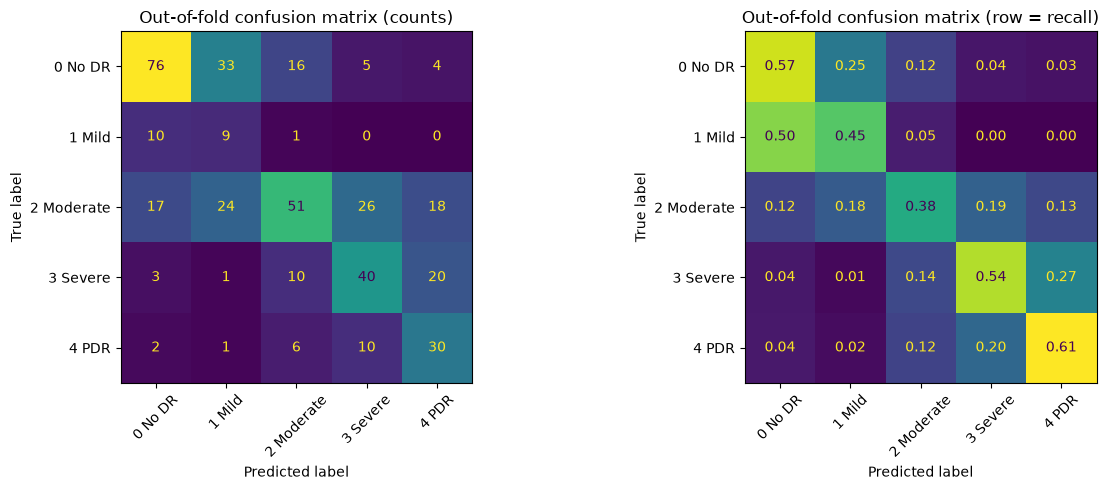

In [29]:
selected = np.array(ALL_FEATURES)[best_model.named_steps["select"].get_support()]
print(f"Selected model: {best_model.named_steps['svm']}")
print(f"Features used ({len(selected)}):",
      ", ".join(f"{f} [{col_to_family[f]}]" for f in selected))

y_oof = cross_val_predict(clone(best_model), X, y, cv=cv, n_jobs=-1)

print("\n" + classification_report(y, y_oof, labels=classes, target_names=GRADE_NAMES,
                                   digits=3, zero_division=0))
abs_err = np.abs(y.values - y_oof)
print(f"QWK (OOF): {cohen_kappa_score(y, y_oof, weights='quadratic'):.4f}")
print(f"Exact: {(abs_err == 0).mean():.3f} | within one grade: {(abs_err <= 1).mean():.3f} "
      f"| off by 2+: {(abs_err >= 2).mean():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay.from_predictions(y, y_oof, labels=classes, display_labels=GRADE_NAMES,
                                        ax=axes[0], colorbar=False, xticks_rotation=45)
axes[0].set_title("Out-of-fold confusion matrix (counts)")
ConfusionMatrixDisplay.from_predictions(y, y_oof, labels=classes, display_labels=GRADE_NAMES,
                                        normalize="true", values_format=".2f",
                                        ax=axes[1], colorbar=False, xticks_rotation=45)
axes[1].set_title("Out-of-fold confusion matrix (row = recall)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "cv_confusion_matrix.png", dpi=150)
plt.show()

## 9. Which features and families matter

Permutation importance measured on **held-out folds**: how much macro-F1 drops when one feature's
values are shuffled. Features not selected in a fold contribute ~0 there.

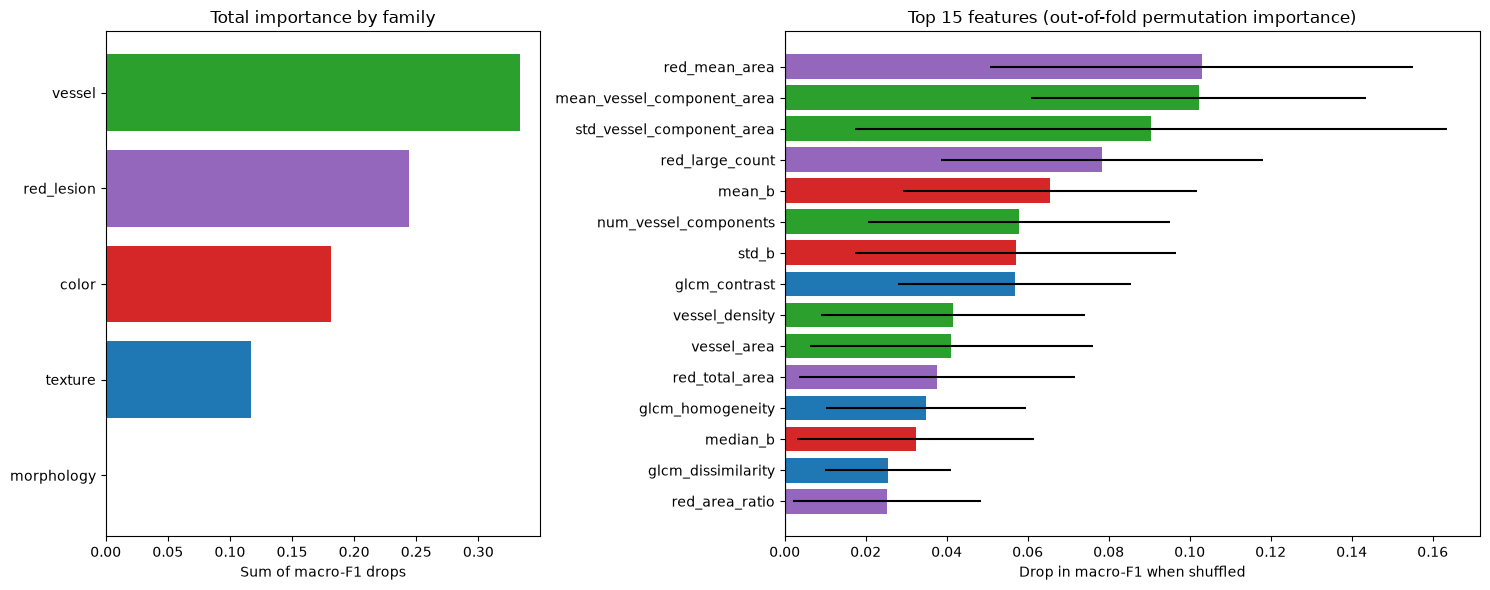

,importance_mean,importance_std,family
red_mean_area,0.1030,0.0523,red_lesion
mean_vessel_component_area,0.1023,0.0413,vessel
std_vessel_component_area,0.0904,0.0731,vessel
red_large_count,0.0784,0.0397,red_lesion
mean_b,0.0655,0.0362,color
num_vessel_components,0.0579,0.0372,vessel
std_b,0.0571,0.0396,color
glcm_contrast,0.0568,0.0288,texture
vessel_density,0.0415,0.0326,vessel
vessel_area,0.0411,0.0349,vessel


In [30]:
fold_imp = []
for train_idx, val_idx in cv.split(X, y):
    fold_model = clone(best_model).fit(X.iloc[train_idx], y.iloc[train_idx])
    r = permutation_importance(fold_model, X.iloc[val_idx], y.iloc[val_idx], scoring="f1_macro",
                               n_repeats=20, random_state=RANDOM_STATE, n_jobs=-1)
    fold_imp.append(r.importances_mean)

imp = pd.DataFrame(fold_imp, columns=ALL_FEATURES)
imp_summary = pd.DataFrame({
    "importance_mean": imp.mean(),
    "importance_std": imp.std(),
    "family": [col_to_family[c] for c in ALL_FEATURES],
}).sort_values("importance_mean", ascending=False)
imp_summary.to_csv(TABLES_DIR / "permutation_importance_oof.csv")

family_colors = {"color": "tab:red", "texture": "tab:blue", "morphology": "tab:orange",
                 "vessel": "tab:green", "red_lesion": "tab:purple"}
family_total = imp_summary.groupby("family")["importance_mean"].sum().sort_values()
top = imp_summary.head(15).iloc[::-1]

fig, axes = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios": [1, 1.6]})
axes[0].barh(family_total.index, family_total.values,
             color=[family_colors[f] for f in family_total.index])
axes[0].set_title("Total importance by family")
axes[0].set_xlabel("Sum of macro-F1 drops")
axes[1].barh(top.index, top["importance_mean"], xerr=top["importance_std"],
             color=[family_colors[f] for f in top["family"]])
axes[1].axvline(0, color="black", lw=0.8)
axes[1].set_title("Top 15 features (out-of-fold permutation importance)")
axes[1].set_xlabel("Drop in macro-F1 when shuffled")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "permutation_importance_oof.png", dpi=150)
plt.show()

imp_summary.head(15).round(4)

In [31]:
y_test_pred = best_model.predict(X_test)
yt, yp = y_test.to_numpy(), np.asarray(y_test_pred)

metric_fns = {
    "accuracy": lambda a, b: accuracy_score(a, b),
    "balanced_accuracy": lambda a, b: balanced_accuracy_score(a, b),
    "f1_macro": lambda a, b: f1_score(a, b, labels=classes, average="macro", zero_division=0),
    "qwk": lambda a, b: cohen_kappa_score(a, b, weights="quadratic"),
}

# Bootstrap: resample the 103 test images with replacement
rng = np.random.default_rng(RANDOM_STATE)
boot = {m: [] for m in metric_fns}
with warnings.catch_warnings():
    warnings.simplefilter("ignore")    # some resamples miss a rare class; expected
    for _ in range(2000):
        idx = rng.integers(0, len(yt), len(yt))
        for m, fn in metric_fns.items():
            boot[m].append(fn(yt[idx], yp[idx]))

test_rows = []
for m, fn in metric_fns.items():
    lo, hi = np.nanpercentile(boot[m], [2.5, 97.5])
    test_rows.append({"metric": m, "value": fn(yt, yp), "ci95_low": lo, "ci95_high": hi})
test_table = pd.DataFrame(test_rows)
test_table.to_csv(TABLES_DIR / "test_metrics.csv", index=False)

abs_err = np.abs(yt - yp)
print(f"Model: {best_model.named_steps['svm']} | features used: {len(selected)}")
print(f"Exact: {(abs_err == 0).mean():.3f} | within one grade: {(abs_err <= 1).mean():.3f}\n")
print(classification_report(yt, yp, labels=classes, target_names=GRADE_NAMES,
                            digits=3, zero_division=0))
test_table.round(4)

Model: SVC(C=1000, class_weight='balanced', gamma=0.001) | features used: 15
Exact: 0.388 | within one grade: 0.777

              precision    recall  f1-score   support

     0 No DR      0.579     0.324     0.415        34
      1 Mild      0.083     0.400     0.138         5
  2 Moderate      0.450     0.281     0.346        32
    3 Severe      0.467     0.737     0.571        19
       4 PDR      0.400     0.308     0.348        13

    accuracy                          0.388       103
   macro avg      0.396     0.410     0.364       103
weighted avg      0.472     0.388     0.401       103



,metric,value,ci95_low,ci95_high
0,accuracy,0.3883,0.2913,0.4854
1,balanced_accuracy,0.4099,0.2892,0.5414
2,f1_macro,0.3637,0.2658,0.4464
3,qwk,0.5899,0.4490,0.7097


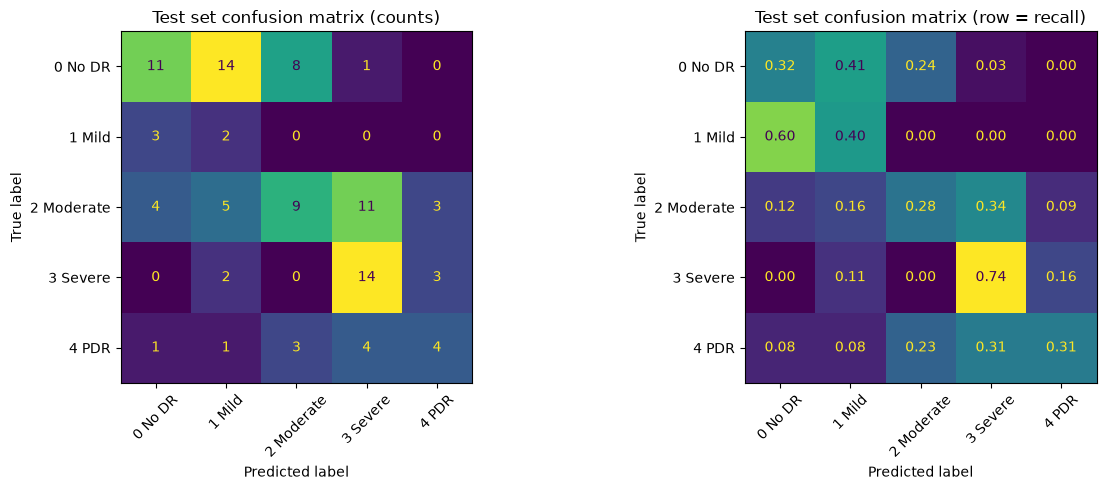

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay.from_predictions(yt, yp, labels=classes, display_labels=GRADE_NAMES,
                                        ax=axes[0], colorbar=False, xticks_rotation=45)
axes[0].set_title("Test set confusion matrix (counts)")
ConfusionMatrixDisplay.from_predictions(yt, yp, labels=classes, display_labels=GRADE_NAMES,
                                        normalize="true", values_format=".2f",
                                        ax=axes[1], colorbar=False, xticks_rotation=45)
axes[1].set_title("Test set confusion matrix (row = recall)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "test_confusion_matrix.png", dpi=150)
plt.show()

# Per-image predictions, for error analysis
pd.DataFrame({
    "image_id": test_df[ID_COL],
    "true_grade": yt,
    "predicted_grade": yp,
    "abs_error": abs_err,
}).to_csv(TABLES_DIR / "test_predictions.csv", index=False)

In [ ]:
model_path = MODELS_DIR / "svm_final.joblib"
joblib.dump({
    "model": best_model,
    "feature_columns": ALL_FEATURES,          # column order expected by the pipeline
    "selected_features": list(selected),
    "best_params": search.best_params_,
    "target": TARGET,
}, model_path)
print("Saved:", model_path)

# Reload example:
# bundle = joblib.load(model_path)
# preds = bundle["model"].predict(new_df[bundle["feature_columns"]])

Best KNN params: {'knn__n_neighbors': 11, 'knn__p': 1, 'knn__weights': 'distance'}


,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,f1_macro_mean,qwk_mean
0,SVM (all 36),0.4916,0.0486,0.4485,0.4197,0.6748
1,KNN (all 36),0.5474,0.0498,0.4266,0.4241,0.6784


              precision    recall  f1-score   support

     0 No DR      0.689     0.843     0.758       134
      1 Mild      0.667     0.100     0.174        20
  2 Moderate      0.538     0.618     0.575       136
    3 Severe      0.489     0.297     0.370        74
       4 PDR      0.467     0.429     0.447        49

    accuracy                          0.586       413
   macro avg      0.570     0.457     0.465       413
weighted avg      0.576     0.586     0.563       413



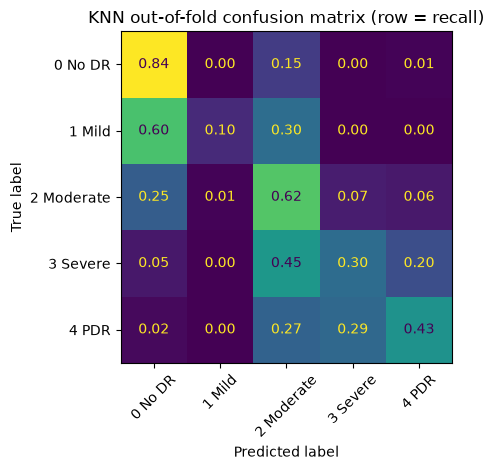

In [33]:
from sklearn.neighbors import KNeighborsClassifier

# Pipeline: all 36 features -> standardize -> KNN
knn_pipe = Pipeline([
    ("scaler", StandardScaler()),          # essential: KNN is purely distance-based
    ("knn", KNeighborsClassifier()),
])

knn_grid = {
    "knn__n_neighbors": [3, 5, 7, 9, 11, 15, 21, 31],
    "knn__weights": ["uniform", "distance"],   # distance: closer neighbours count more
    "knn__p": [1, 2],                          # 1 = Manhattan, 2 = Euclidean
}

knn_search = GridSearchCV(knn_pipe, knn_grid, cv=cv, scoring=SCORING, refit=REFIT, n_jobs=-1)
knn_search.fit(X, y)
print("Best KNN params:", knn_search.best_params_)

# Honest estimate: nested CV (same outer folds as the SVM in Section 7)
knn_nested = cross_validate(
    GridSearchCV(knn_pipe, knn_grid, cv=cv, scoring=SCORING, refit=REFIT, n_jobs=-1),
    X, y, cv=outer_cv, scoring=SCORING,
)
comparison = pd.concat([
    nested_table[nested_table["model"].str.startswith("all 36")].assign(model="SVM (all 36)"),
    pd.DataFrame([summarize("KNN (all 36)", knn_nested)]),
], ignore_index=True)
display(comparison[["model", "accuracy_mean", "accuracy_std", "balanced_accuracy_mean",
                    "f1_macro_mean", "qwk_mean"]].round(4))

# Where KNN errs (out-of-fold, training set)
y_oof_knn = cross_val_predict(clone(knn_search.best_estimator_), X, y, cv=cv, n_jobs=-1)
print(classification_report(y, y_oof_knn, labels=classes, target_names=GRADE_NAMES,
                            digits=3, zero_division=0))
ConfusionMatrixDisplay.from_predictions(y, y_oof_knn, labels=classes, display_labels=GRADE_NAMES,
                                        normalize="true", values_format=".2f",
                                        colorbar=False, xticks_rotation=45)
plt.title("KNN out-of-fold confusion matrix (row = recall)")
plt.tight_layout()
plt.show()

# Test set: only if KNN clearly beats the SVM in nested CV above
RUN_TEST = False
if RUN_TEST:
    y_knn_test = knn_search.best_estimator_.predict(X_test)
    print(f"KNN test accuracy: {accuracy_score(y_test, y_knn_test):.4f} | "
          f"macro-F1: {f1_score(y_test, y_knn_test, average='macro'):.4f} | "
          f"QWK: {cohen_kappa_score(y_test, y_knn_test, weights='quadratic'):.4f}")

Best LogReg params: {'logreg__C': 0.01}


,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,f1_macro_mean,qwk_mean
0,SVM (all 36),0.4916,0.0486,0.4485,0.4197,0.6748
1,KNN (all 36),0.5474,0.0498,0.4266,0.4241,0.6784
2,LogReg (all 36),0.5060,0.0346,0.5227,0.4622,0.6980


              precision    recall  f1-score   support

     0 No DR      0.706     0.575     0.634       134
      1 Mild      0.135     0.600     0.220        20
  2 Moderate      0.549     0.331     0.413       136
    3 Severe      0.483     0.392     0.433        74
       4 PDR      0.425     0.633     0.508        49

    accuracy                          0.470       413
   macro avg      0.460     0.506     0.442       413
weighted avg      0.553     0.470     0.490       413



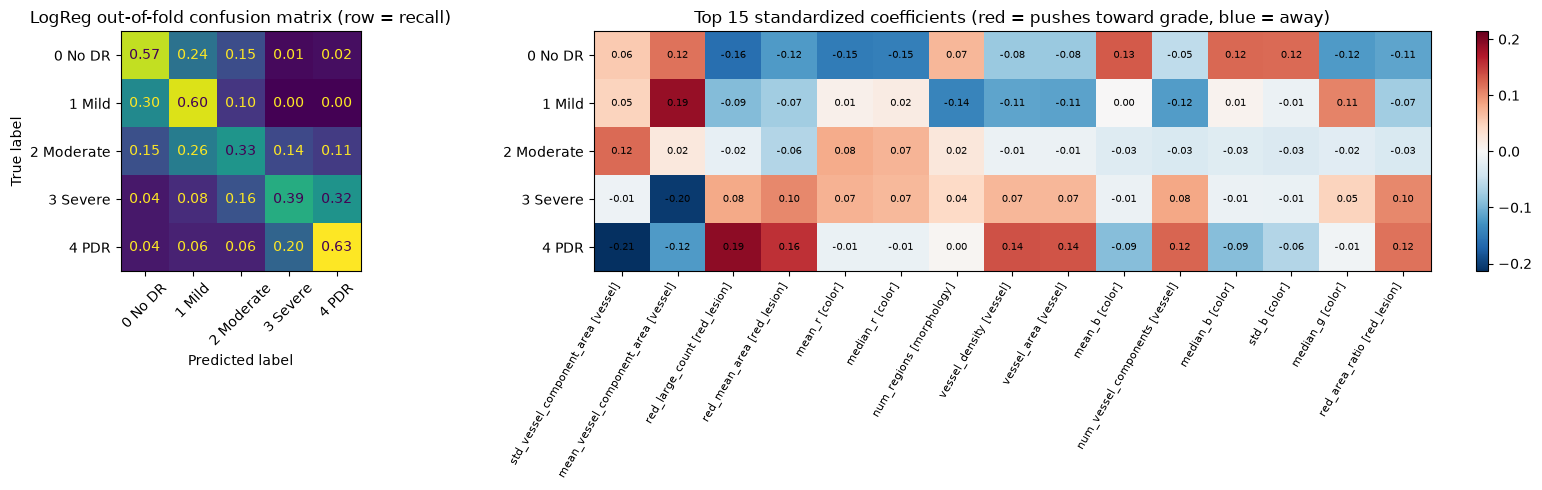

In [34]:
from sklearn.linear_model import LogisticRegression

# Pipeline: all 36 features -> standardize -> multinomial logistic regression
logreg_pipe = Pipeline([
    ("scaler", StandardScaler()),          # needed: regularization treats all features equally only on a common scale
    ("logreg", LogisticRegression(class_weight="balanced", max_iter=5000)),
])

logreg_grid = {"logreg__C": [0.001, 0.01, 0.1, 1, 10, 100]}   # smaller C = stronger regularization

logreg_search = GridSearchCV(logreg_pipe, logreg_grid, cv=cv, scoring=SCORING, refit=REFIT, n_jobs=-1)
logreg_search.fit(X, y)
print("Best LogReg params:", logreg_search.best_params_)

# Honest estimate: nested CV, same outer folds as the SVM (Section 7) and KNN
logreg_nested = cross_validate(
    GridSearchCV(logreg_pipe, logreg_grid, cv=cv, scoring=SCORING, refit=REFIT, n_jobs=-1),
    X, y, cv=outer_cv, scoring=SCORING,
)
rows = [nested_table[nested_table["model"].str.startswith("all 36")].assign(model="SVM (all 36)")]
if "knn_nested" in globals():
    rows.append(pd.DataFrame([summarize("KNN (all 36)", knn_nested)]))
rows.append(pd.DataFrame([summarize("LogReg (all 36)", logreg_nested)]))
display(pd.concat(rows, ignore_index=True)[
    ["model", "accuracy_mean", "accuracy_std", "balanced_accuracy_mean", "f1_macro_mean", "qwk_mean"]
].round(4))

# Where it errs (out-of-fold, training set)
y_oof_lr = cross_val_predict(clone(logreg_search.best_estimator_), X, y, cv=cv, n_jobs=-1)
print(classification_report(y, y_oof_lr, labels=classes, target_names=GRADE_NAMES,
                            digits=3, zero_division=0))

# Interpretability: standardized coefficients of the final model (fit on all training data)
# Value = change in a grade's log-odds per +1 std of the feature (relative to the other grades).
# Correlated features (e.g. mean_g / median_g) share weight, so read families, not single numbers.
coef = pd.DataFrame(logreg_search.best_estimator_.named_steps["logreg"].coef_,
                    index=GRADE_NAMES, columns=X.columns)
top = coef.abs().max().sort_values(ascending=False).head(15).index
lim = np.abs(coef[top].values).max()

fig, axes = plt.subplots(1, 2, figsize=(17, 5), gridspec_kw={"width_ratios": [1, 1.6]})
ConfusionMatrixDisplay.from_predictions(y, y_oof_lr, labels=classes, display_labels=GRADE_NAMES,
                                        normalize="true", values_format=".2f", ax=axes[0],
                                        colorbar=False, xticks_rotation=45)
axes[0].set_title("LogReg out-of-fold confusion matrix (row = recall)")
im = axes[1].imshow(coef[top].values, cmap="RdBu_r", vmin=-lim, vmax=lim, aspect="auto")
axes[1].set_xticks(range(len(top)))
axes[1].set_xticklabels([f"{f} [{col_to_family[f]}]" for f in top], rotation=60, ha="right", fontsize=8)
axes[1].set_yticks(range(5))
axes[1].set_yticklabels(GRADE_NAMES)
for i in range(5):
    for j in range(len(top)):
        axes[1].text(j, i, f"{coef[top].values[i, j]:.2f}", ha="center", va="center", fontsize=7)
axes[1].set_title("Top 15 standardized coefficients (red = pushes toward grade, blue = away)")
plt.colorbar(im, ax=axes[1], fraction=0.03)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "logreg_oof_cm_and_coefficients.png", dpi=150)
plt.show()

# Test set: only if LogReg clearly beats the SVM in nested CV above
RUN_TEST = False
if RUN_TEST:
    y_lr_test = logreg_search.best_estimator_.predict(X_test)
    print(f"LogReg test accuracy: {accuracy_score(y_test, y_lr_test):.4f} | "
          f"macro-F1: {f1_score(y_test, y_lr_test, average='macro'):.4f} | "
          f"QWK: {cohen_kappa_score(y_test, y_lr_test, weights='quadratic'):.4f}")